In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Activation
from tensorflow.keras.optimizers import RMSprop, Adam
from matplotlib import pyplot as plt
import numpy as np
import math

In [ ]:
loss_tracker = tf.keras.metrics.Mean(name="loss")

class inciso_2a(tf.keras.Model):
    def __init__(self):
        super(inciso_2a, self).__init__()

        self.dense1 = tf.keras.layers.Dense(32, activation='relu', input_shape=(1,))  
        self.dense2 = tf.keras.layers.Dense(32, activation='relu')  
        self.output_layer = tf.keras.layers.Dense(1)  

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

    @property
    def metrics(self):
        return [loss_tracker] 

    def train_step(self, data):
        batch_size = 10  
        x = tf.random.uniform((batch_size, 1), minval=-1, maxval=1) 
        eq = 3 * tf.math.sin(tf.constant(math.pi) * x)

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            functionloss = tf.keras.losses.MeanSquaredError()
            loss = functionloss(y_pred, eq)

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        

        loss_tracker.update_state(loss)

        return {"loss": loss_tracker.result()}

In [3]:
modelo_a = inciso_2a()  
modelo_a.build(input_shape=(None, 1))
modelo_a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))
modelo_a.summary()

c:\Users\Oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'inciso_2a', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "inciso_2a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
import numpy as np 
datos_vacios=[np.linspace(10,100,100),np.linspace(10,100,100)]
history_a = modelo_a.fit(datos_vacios,epochs=1000, steps_per_epoch=100, verbose=1)

Epoch 1/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3427
Epoch 2/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3940
Epoch 3/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0502
Epoch 4/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0068
Epoch 5/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043
Epoch 6/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022
Epoch 7/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038
Epoch 8/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022
Epoch 9/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014    
Epoch 10/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036
Epoch 11/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056
Epoch 12/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160
Epoch 13/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102
Epoch 14/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057
Epoch 15/1000
100/100 ━━━

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step


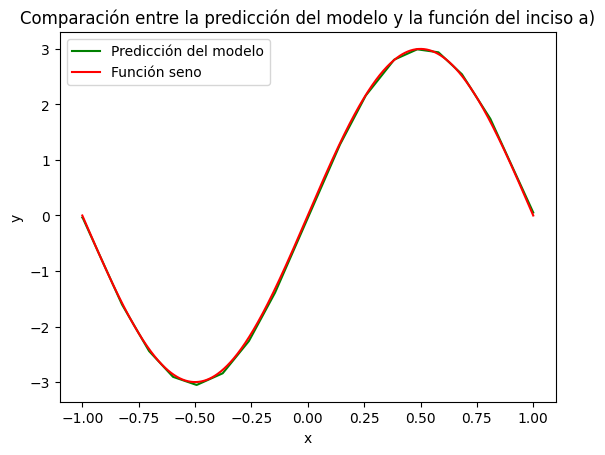

In [11]:
import matplotlib.pyplot as plt
x_testv = tf.linspace(-1, 1, 1000) 
x_testv = tf.expand_dims(x_testv, axis=1)
a = modelo_a.predict(x_testv)
y_real = 3 * tf.math.sin(tf.constant(math.pi, dtype=tf.float32) * tf.cast(x_testv, tf.float32)) 


plt.plot(x_testv, a, label="Predicción del modelo", color='green')
plt.plot(x_testv, y_real, label="Función seno", color='red')
plt.title("Comparación entre la predicción del modelo y la función del inciso a)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [6]:
class inciso_2b(tf.keras.Model):
    def __init__(self):
        super(inciso_2b, self).__init__()

        self.dense1 = tf.keras.layers.Dense(32, activation='relu', input_shape=(1,))  
        self.dense2 = tf.keras.layers.Dense(32, activation='relu')  
        self.output_layer = tf.keras.layers.Dense(1)  

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

    @property
    def metrics(self):
        return [loss_tracker] 

    def train_step(self, data):
        batch_size = 10  
        x = tf.random.uniform((batch_size, 1), minval=-1, maxval=1) 
        x = tf.expand_dims(x, axis=-1)
        eq = 1+2*x+4*x**3

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            funcionloss = tf.keras.losses.MeanSquaredError()
            loss=funcionloss(y_pred,eq)

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        

        loss_tracker.update_state(loss)

        return {"loss": loss_tracker.result()}

In [7]:
modelo_b = inciso_2b()  
modelo_b.build(input_shape=(None, 1))
modelo_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))
modelo_b.summary()

c:\Users\Oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'inciso_2b', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "inciso_2b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
import numpy as np 
datos_vacios=[np.linspace(10,100,100),np.linspace(10,100,100)]
history_b = modelo_b.fit(datos_vacios,epochs=1000, steps_per_epoch=100, verbose=1)

Epoch 1/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0068  
Epoch 2/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0486  
Epoch 3/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119  
Epoch 4/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0140  
Epoch 5/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0058  
Epoch 6/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0023   
Epoch 7/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018  
Epoch 8/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0025  
Epoch 9/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0165  
Epoch 10/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046  
Epoch 11/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012      
Epoch 12/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.0021 
Epoch 13/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016  
Epoch 14/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 6.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


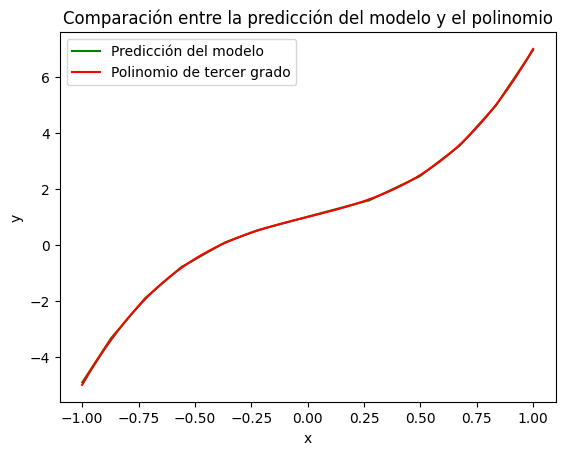

In [9]:
import matplotlib.pyplot as plt
x_testv = tf.linspace(-1, 1, 1000) 
x_testv = tf.expand_dims(x_testv, axis=1)
b = modelo_b.predict(x_testv)
y_real = 1+2*x_testv+4*x_testv**3


plt.plot(x_testv, b, label="Predicción del modelo", color='green')
plt.plot(x_testv, y_real, label="Polinomio de tercer grado", color='red')
plt.title("Comparación entre la predicción del modelo y el polinomio")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()